conda create -n ai-econ-legacy python=3.7.16 -y
conda activate ai-econ-legacy

pip install "numpy==1.16.4"
pip install "tensorflow==1.14.0"
pip install "gym<0.23"
pip install "ray[rllib]==1.13.0"
pip install jupyter ipykernel tensorboard
python -m ipykernel install --user --name ai-econ-legacy --display-name "Python (ai-econ-legacy)"

In [1]:
import sys
import ray
import numpy as np
import tensorflow as tf
import gym


import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd

import random

c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\s

In [2]:
sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

from utils import plotting

import ray
from ray.rllib.agents.ppo import PPOTrainer

C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-


In [3]:
from rllib.env_wrapper import RLlibEnvWrapper


# training sim

In [4]:
import os
import warnings

# TensorFlow / C++ logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Python warnings
warnings.filterwarnings("ignore")

# Ray logging
os.environ["RAY_DISABLE_IMPORT_WARNING"] = "1"
os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1"

import simulation as exp

import ray
ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False, logging_level="ERROR")

settings = exp.ExperimentSettings(
    phase1_iters = 50,
    phase2_iters = 120,
    phase3a_iters = 50,
    phase3b_iters = 120,
    save_results=False,
    travel_enabled_phase3a=False,
    travel_enabled_phase3b=False,
    restrict_trade_to_region = True,
    experiment_extra_tag = "Original_with_travel",

    num_workers=0,
    num_envs_per_worker=1,
    num_gpus=1,
    rollout_fragment_length=100,
    train_batch_size=500,
    sgd_minibatch_size=100,
    num_sgd_iter=2,

    # train_batch_size=6000,      # 15 workers * 2 envs * 200 steps
    # sgd_minibatch_size=1500,
    # num_sgd_iter=4,    
    


)

results = exp.run_experiment(settings)

2026-04-24 16:18:13,560	ERROR syncer.py:46 -- Log sync requires rsync to be installed.


Skipping saving results (save_results=False)
Instructions for updating:
Use `tf.random.categorical` instead.
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Instructions for updating:
Prefer Variable.assign which has equivalent behavior in 2.X.
[PHASE 1] Iter=0000/50 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 59.90641131365807
[PHASE 1] Iter=0025/50 reward=481.82138089935546
   p_top reward: 104.12172135650354, p_bottom reward: 102.10694811051303
   social welfare (coin_eq_times_prod): 0.0
[PHASE 1] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-24_16-18-13889kfvd8\checkpoint_50\checkpoint-50  (4.5 min)


2026-04-24 16:23:17,377	ERROR syncer.py:46 -- Log sync requires rsync to be installed.


[PHASE 2] Iter=0000/120 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 160.74412593421152
[PHASE 2] Iter=0025/120 reward=987.3080783253561
   p_top reward: 267.7312662895753, p_bottom reward: 219.0520552155502
   social welfare (coin_eq_times_prod): 0.0
[PHASE 2] Iter=0050/120 reward=952.8892671025726
   p_top reward: 241.28511490571077, p_bottom reward: 230.37251983720384
   social welfare (coin_eq_times_prod): 111.86286713330895
[PHASE 2] Iter=0075/120 reward=934.8250114419184
   p_top reward: 233.67196602138972, p_bottom reward: 227.70314256475726
   social welfare (coin_eq_times_prod): 0.0
[PHASE 2] Iter=0100/120 reward=961.5268455162302
   p_top reward: 237.14993165133686, p_bottom reward: 238.27064719807169
   social welfare (coin_eq_times_prod): 142.83685858951776
[PHASE 2] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-24_16-23-17e7pd_orf\checkpoint_120\checkpoint-120  (11.5 min)


2026-04-24 16:35:40,484	ERROR syncer.py:46 -- Log sync requires rsync to be installed.


[PHASE 3A] Iter=0000/50 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 111.81764955964675
[PHASE 3A] Iter=0025/50 reward=1002.1583333167257
   p_top reward: 216.16415892915222, p_bottom reward: 260.62993432873554
   social welfare (coin_eq_times_prod): 0.0
[PHASE 3A] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-24_16-35-407ww9gwn5\checkpoint_50\checkpoint-50  (5.4 min)


2026-04-24 16:41:40,839	ERROR syncer.py:46 -- Log sync requires rsync to be installed.


[PHASE 3B] Iter=0000/120 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 150.86358973435668
[PHASE 3B] Iter=0025/120 reward=900.4061082489467
   p_top reward: 231.87625731324047, p_bottom reward: 205.92022501577006
   social welfare (coin_eq_times_prod): 0.0
[PHASE 3B] Iter=0050/120 reward=999.0233151029996
   p_top reward: 255.5133062605393, p_bottom reward: 231.9502629454915
   social welfare (coin_eq_times_prod): 187.27962037001853
[PHASE 3B] Iter=0075/120 reward=1024.1340564523591
   p_top reward: 264.08918144078217, p_bottom reward: 229.93180261345807
   social welfare (coin_eq_times_prod): 0.0
[PHASE 3B] Iter=0100/120 reward=1037.4040166333061
   p_top reward: 267.2300792421248, p_bottom reward: 234.14191944165768
   social welfare (coin_eq_times_prod): 156.4005287539059
[PHASE 3B] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-24_16-41-40xmagoguf\checkpoint_120\checkpoint-120  (15.5 min)
p_top (#decision_row

In [5]:
results["summary"]
results["metrics_df"]

dense_logs = results["dense_logs"]

In [6]:
phase_envs = exp.build_all_phase_env_configs(settings)

env_config_dict_phase3b = phase_envs["phase3b"]

env_obj_phase1 = results["envs"]["phase1"]
env_obj_phase3b = results["envs"]["phase3b"]

trainer_phase3b = results["trainers"]["phase3b"]

In [7]:
state0 = dense_logs[0]["states"][0]
for aid in sorted(int(k) for k in state0 if str(k).isdigit()):
    s = state0[str(aid)]
    row = int(s["loc"][0])
    region_from_loc = "top" if row < 25 else "bottom"
    print(aid, s["loc"], region_from_loc)

0 [0, 0] top
1 [24, 0] top
2 [0, 24] top
3 [24, 24] top
4 [26, 0] bottom
5 [50, 0] bottom
6 [26, 24] bottom
7 [50, 24] bottom


In [8]:
last_state = dense_logs[0]["states"][-1]
for aid in sorted(int(k) for k in last_state if str(k).isdigit()):
    s = last_state[str(aid)]
    row = int(s["loc"][0])
    region_from_loc = "top" if row < 25 else "bottom"
    print(aid, s["loc"], "cached:", s.get("region"), "from_loc:", region_from_loc)

0 [0, 7] cached: None from_loc: top
1 [2, 3] cached: None from_loc: top
2 [0, 11] cached: None from_loc: top
3 [0, 19] cached: None from_loc: top
4 [32, 1] cached: None from_loc: bottom
5 [26, 9] cached: None from_loc: bottom
6 [26, 24] cached: None from_loc: bottom
7 [28, 2] cached: None from_loc: bottom


In [9]:
states = dense_logs[0]["states"]

for aid in range(8):
    rows = [int(s[str(aid)]["loc"][0]) for s in states]
    started_top = rows[0] < 25
    ever_crossed = any((r >= 25) for r in rows) if started_top else any((r < 25) for r in rows)
    print(aid, "started_top" if started_top else "started_bottom", "ever_crossed =", ever_crossed)

0 started_top ever_crossed = False
1 started_top ever_crossed = False
2 started_top ever_crossed = False
3 started_top ever_crossed = False
4 started_bottom ever_crossed = False
5 started_bottom ever_crossed = False
6 started_bottom ever_crossed = False
7 started_bottom ever_crossed = False


In [10]:
for t, state in enumerate(dense_logs[0]["states"]):
    vals = []
    for i in range(8):
        s = state[str(i)]
        vals.append((i, s.get("loc", None), s.get("location_region", None)))
    print(t, vals)

0 [(0, [0, 0], 'top'), (1, [24, 0], 'bottom'), (2, [0, 24], 'top'), (3, [24, 24], 'bottom'), (4, [26, 0], 'top'), (5, [50, 0], 'top'), (6, [26, 24], 'top'), (7, [50, 24], 'bottom')]
1 [(0, [0, 0], 'top'), (1, [24, 0], 'bottom'), (2, [0, 23], 'top'), (3, [24, 23], 'bottom'), (4, [26, 0], 'top'), (5, [50, 0], 'top'), (6, [26, 24], 'top'), (7, [50, 24], 'bottom')]
2 [(0, [0, 1], 'top'), (1, [24, 1], 'bottom'), (2, [0, 22], 'top'), (3, [24, 22], 'bottom'), (4, [27, 0], 'top'), (5, [50, 1], 'top'), (6, [26, 23], 'top'), (7, [50, 24], 'bottom')]
3 [(0, [0, 1], 'top'), (1, [24, 2], 'bottom'), (2, [0, 22], 'top'), (3, [24, 22], 'bottom'), (4, [28, 0], 'top'), (5, [50, 2], 'top'), (6, [26, 22], 'top'), (7, [50, 23], 'bottom')]
4 [(0, [0, 2], 'top'), (1, [24, 3], 'bottom'), (2, [0, 22], 'top'), (3, [24, 22], 'bottom'), (4, [29, 0], 'top'), (5, [50, 2], 'top'), (6, [26, 23], 'top'), (7, [50, 23], 'bottom')]
5 [(0, [1, 2], 'top'), (1, [24, 3], 'bottom'), (2, [1, 22], 'top'), (3, [24, 21], 'bottom'

In [11]:
from tutorials import simulation as sim

print("In-memory summary:", sim.summarize_dense_log(dense_logs[0]))

last_state = dense_logs[0]["states"][-1]
counts = {"top": 0, "bottom": 0}
for i in range(8):
    region = last_state[str(i)]["location_region"]
    counts[region] += 1
    print(i, last_state[str(i)]["loc"], region)

print("Direct final counts:", counts)

C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-
In-memory summary: {'mean_final_coin': 207.78994168716838, 'std_final_coin': 62.361562038621976, 'mean_final_labor': 171.1612500000005, 'n_trades': 428, 'n_builds': 122, 'total_build_income': 1662.3195334973475, 'n_travel': 0, 'n_top_final': 4, 'n_bottom_final': 4}
0 [0, 7] top
1 [2, 3] bottom
2 [0, 11] top
3 [0, 19] bottom
4 [32, 1] top
5 [26, 9] top
6 [26, 24] top
7 [28, 2] bottom
Direct final counts: {'top': 5, 'bottom': 3}


In [12]:
last_state = dense_logs[0]["states"][-1]

counts = {"top": 0, "bottom": 0}
for i in range(8):
    state = last_state[str(i)]
    region = state.get("location_region")
    loc = state.get("loc")
    print(i, loc, region)
    if region in counts:
        counts[region] += 1

print("final counts:", counts)

0 [0, 7] top
1 [2, 3] bottom
2 [0, 11] top
3 [0, 19] bottom
4 [32, 1] top
5 [26, 9] top
6 [26, 24] top
7 [28, 2] bottom
final counts: {'top': 5, 'bottom': 3}


In [13]:
last_state = dense_logs[0]["states"][-1]
for i in range(8):
    s = last_state[str(i)]
    print(i, "loc:", s.get("loc"), "region:", s.get("location_region"))

0 loc: [0, 7] region: top
1 loc: [2, 3] region: bottom
2 loc: [0, 11] region: top
3 loc: [0, 19] region: bottom
4 loc: [32, 1] region: top
5 loc: [26, 9] region: top
6 loc: [26, 24] region: top
7 loc: [28, 2] region: bottom


In [14]:
def summarize_travel_events(dense_log):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]

    counts = {}
    for e in events:
        aid = e["agent"]
        counts[aid] = counts.get(aid, 0) + 1

    print("Successful travels per agent:")
    for aid in sorted(counts):
        print(f"Agent {aid}: {counts[aid]}")

    print("Total successful travels:", sum(counts.values()))

summarize_travel_events(dense_logs[0])

def print_travel_events(dense_log, max_events=30):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]
    print(f"Showing first {min(len(events), max_events)} travel events:")
    for e in events[:max_events]:
        print(e)

print_travel_events(dense_logs[0], max_events=50)

def check_travel_cooldowns(dense_log, agent_id=0):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    ts = [e["t"] for e in dense_log["CrossWaterTravel"] if e["agent"] == agent_id]
    print("Travel times:", ts)

    if len(ts) > 1:
        gaps = [ts[i+1] - ts[i] for i in range(len(ts)-1)]
        print("Gaps:", gaps)

check_travel_cooldowns(dense_logs[0], agent_id=0)

Successful travels per agent:
Total successful travels: 0
Showing first 0 travel events:
Travel times: []


In [15]:
def build_counts_by_agent(dense_log):
    counts = {}
    for b in dense_log.get("Build", []):
        events = b.get("builds", []) if isinstance(b, dict) else b
        for ev in events:
            builder = str(ev.get("builder"))
            counts[builder] = counts.get(builder, 0) + 1
    print("build counts by agent:", counts)
    print("total builds:", sum(counts.values()))
    return counts

In [16]:
build_counts_by_agent(dense_logs[0])

build counts by agent: {'4': 27, '6': 9, '5': 19, '2': 14, '1': 14, '0': 23, '7': 5, '3': 11}
total builds: 122


{'4': 27, '6': 9, '5': 19, '2': 14, '1': 14, '0': 23, '7': 5, '3': 11}

In [17]:
obs = env_obj_phase3b.reset()

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :   3.18 (n= 39) |   2.69 (n= 16) |   2.91 (n= 32) |   3.44 (n= 52) |   2.50 (n= 20) |   2.29 (n= 21) |   3.41 (n= 29) |   2.29 (n= 21)
Cost (Stone)   :   4.62 (n= 26) |   5.17 (n= 23) |   5.35 (n= 31) |   5.12 (n= 25) |   5.37 (n= 27) |   5.60 (n= 15) |   5.15 (n= 20) |   5.29 (n= 31)

Income (Wood)  :   3.22 (n= 45) |   2.47 (n= 17) |   3.18 (n= 34) |   3.56 (n= 25) |   1.91 (n= 22) |   2.35 (n= 17) |   3.19 (n= 48) |   2.95 (n= 22)
Income (Stone) :   4.38 (n= 24) |   5.21 (n= 24) |   5.92 (n= 36) |   4.62 (n= 32) |   4.23 (n= 13) |   5.71 (n= 42) |   5.10 (n= 10) |   5.41 (n= 17)
Income (Build) :  10.13 (n= 27) |  10.92 (n= 23) |  11.83 (n=  5) |  12.02 (n= 19) |  14.35 (n= 11) |  17.38 (n= 14) |  17.85 (n=  9) |  20.60 (n= 14)


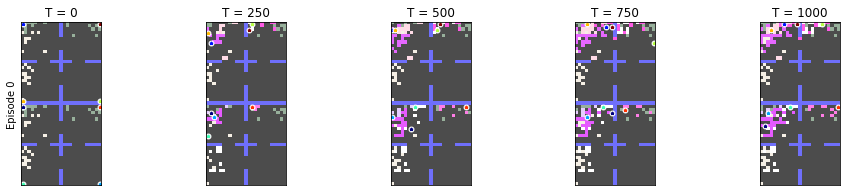

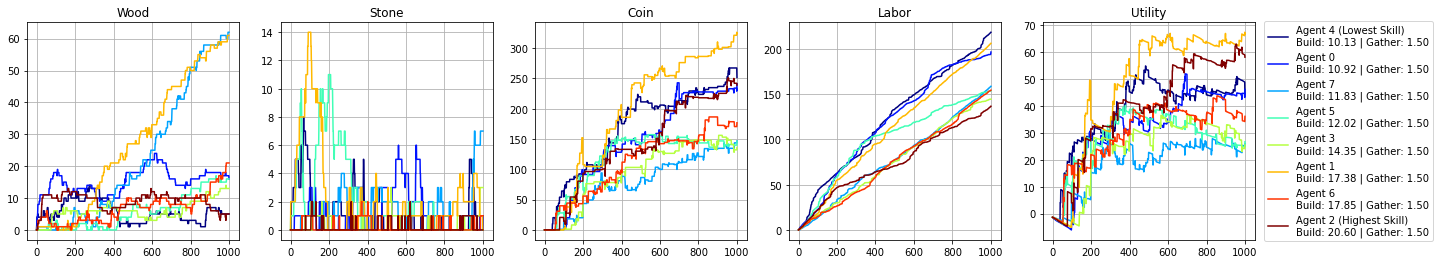

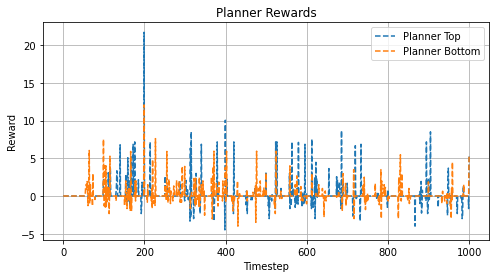

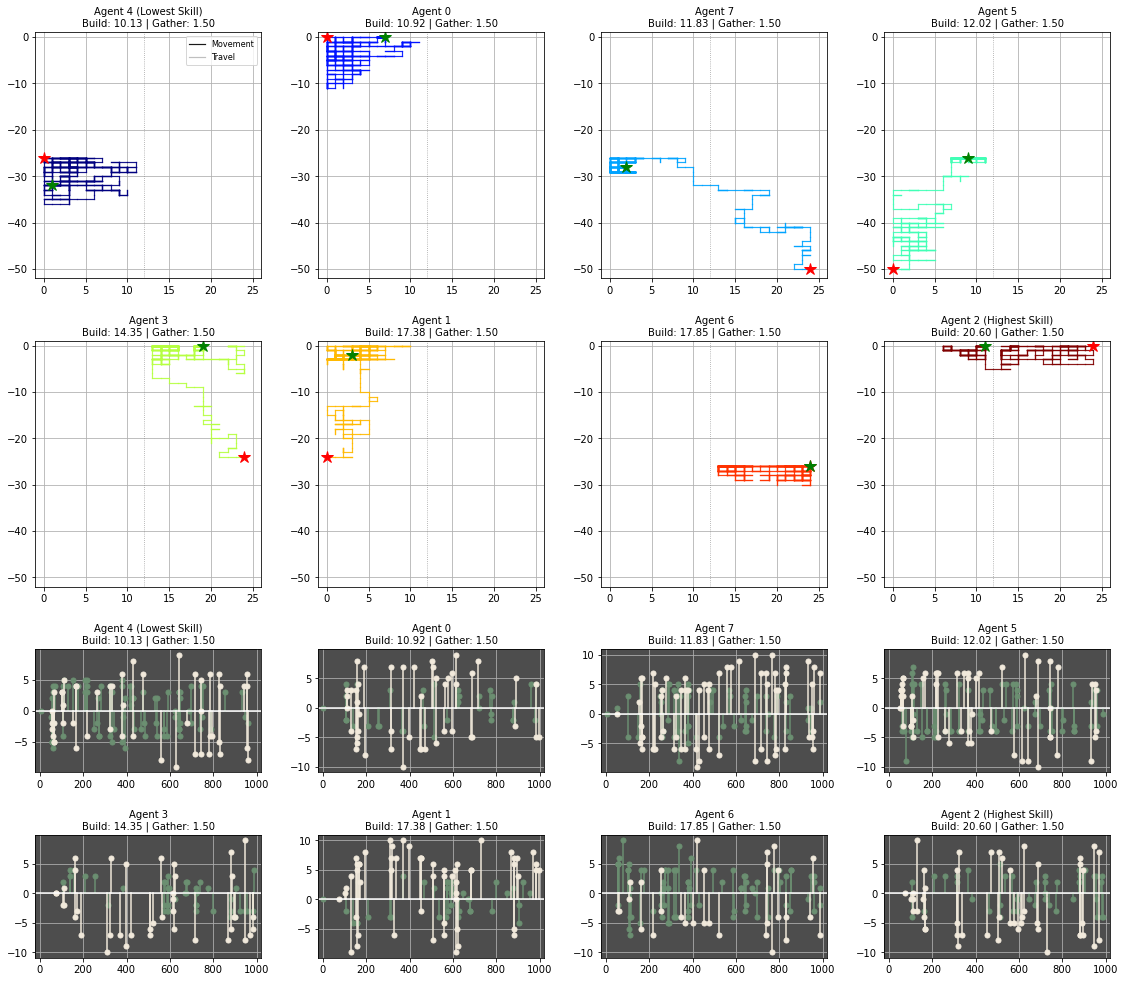

In [18]:
(fig0, fig1, fig1_planner, fig2), incomes, endows, c_trades, all_builds = plotting.breakdown_all_agents(
    dense_logs[0],
    n_cols=4,
)

,tax_period,stone_trades,stone_inventory_total,stone_escrow_total,stone_on_map,builds
0,0,13,7.71,8.56,34.5,13.0
1,1,39,13.05,5.63,23.0,32.0
2,2,11,6.86,4.05,20.0,13.0
3,3,26,3.74,5.41,24.5,21.0
4,4,16,2.84,2.80,24.0,10.0
5,5,19,4.57,2.43,27.0,8.0
6,6,20,2.08,3.62,31.5,11.0
7,7,19,1.84,0.59,34.0,4.0
8,8,16,0.87,1.96,36.5,4.0
9,9,19,5.87,3.30,35.0,6.0


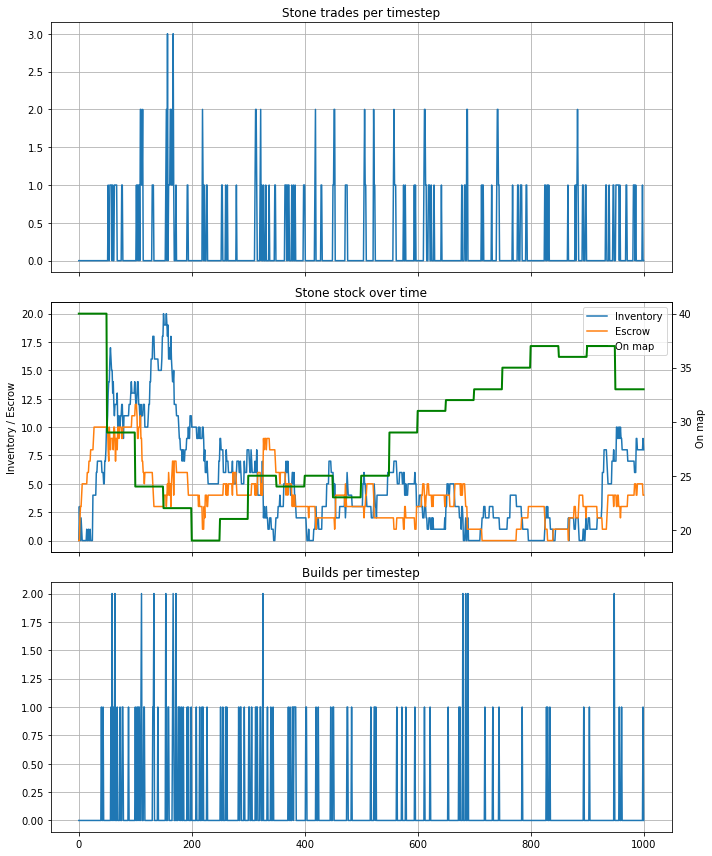

In [19]:
df_stone_t, df_stone_p, fig = plotting.diagnose_resource_market(dense_logs[0], resource="Stone", period=100)
df_stone_p

,tax_period,wood_trades,wood_inventory_total,wood_escrow_total,wood_on_map,builds
0,0,5,12.45,15.91,34.0,11.0
1,1,17,21.14,15.50,25.0,23.0
2,2,18,22.98,20.83,22.0,20.0
3,3,18,21.52,24.33,24.0,15.0
4,4,26,41.73,22.06,24.0,9.0
5,5,24,65.47,29.09,21.5,6.0
6,6,27,77.11,28.80,22.0,12.0
7,7,27,88.25,25.22,22.0,12.0
8,8,24,100.50,25.58,23.0,10.0
9,9,21,122.25,28.06,17.0,9.0


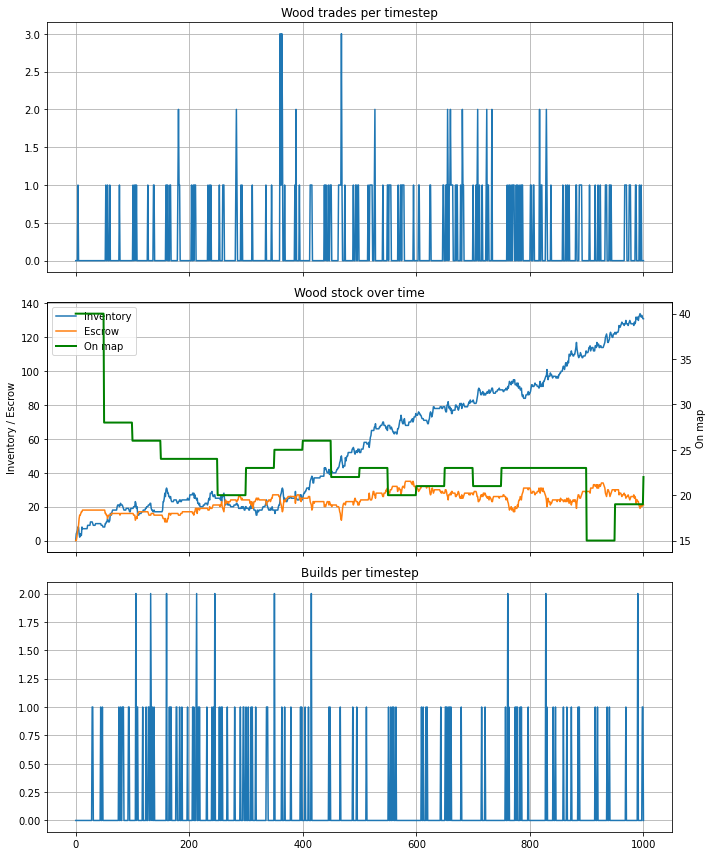

In [20]:
df_wood_t, df_wood_p, fig = plotting.diagnose_resource_market(dense_logs[1], resource="Wood", period=100)
df_wood_p

In [21]:
df_income, df_tax_counts = plotting.tax_day_income_report(dense_logs[0], period=100)
df_income.head(20)
df_tax_counts

,tax_day_number,region,tax_bracket,n_agents
0,1,bottom,"[0.000, 9.700)",1
1,1,bottom,"[39.475, 84.200)",2
2,1,bottom,"[9.700, 39.475)",1
3,1,top,"[0.000, 9.700)",3
4,1,top,"[9.700, 39.475)",1
5,2,bottom,"[0.000, 9.700)",1
6,2,bottom,"[39.475, 84.200)",1
7,2,bottom,"[9.700, 39.475)",2
8,2,top,"[39.475, 84.200)",1
9,2,top,"[84.200, 160.725)",2


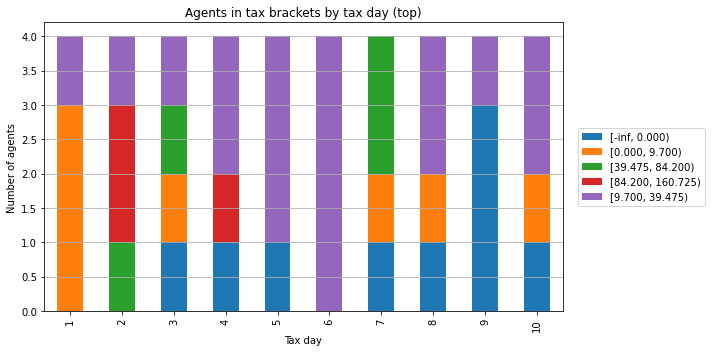

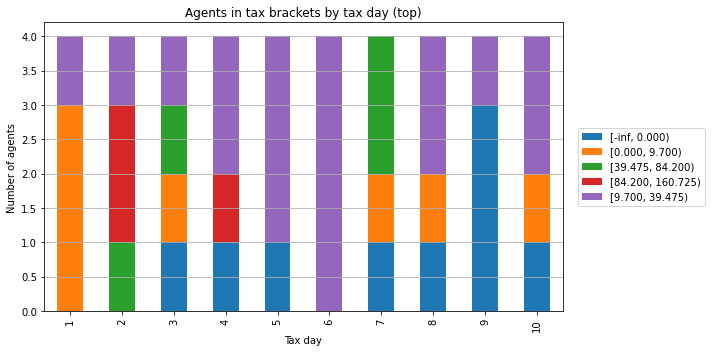

In [22]:
import matplotlib.pyplot as plt

def plot_tax_group_counts(df_counts, region=None):
    df = df_counts.copy()
    if region is not None:
        df = df[df["region"] == region]

    pivot = df.pivot_table(
        index="tax_day_number",
        columns="tax_bracket",
        values="n_agents",
        aggfunc="sum",
        fill_value=0,
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax)

    title = "Agents in tax brackets by tax day"
    if region is not None:
        title += f" ({region})"
    ax.set_title(title)
    ax.set_xlabel("Tax day")
    ax.set_ylabel("Number of agents")
    ax.grid(True, axis="y")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    return fig, pivot

fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")
fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")

In [23]:
df_inv = plotting.inventory_table_by_tax_period(dense_logs[0], period=100, include_escrow=True)
df_inv

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,None,0.000000,13.0,1.0,0.0,5.0,2.0,0.000000,18.0,3.0
1,1,99,1,None,0.000000,0.0,11.0,0.0,1.0,3.0,0.000000,1.0,14.0
2,1,99,2,None,17.596912,5.0,0.0,3.0,5.0,0.0,20.596912,10.0,0.0
3,1,99,3,None,0.000000,4.0,0.0,0.0,2.0,0.0,0.000000,6.0,0.0
4,1,99,4,None,55.160000,5.0,2.0,9.0,1.0,3.0,64.160000,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,None,129.163634,9.0,1.0,3.0,4.0,2.0,132.163634,13.0,3.0
76,10,999,4,None,260.363080,3.0,1.0,7.0,2.0,0.0,267.363080,5.0,1.0
77,10,999,5,None,126.931021,13.0,0.0,13.0,3.0,0.0,139.931021,16.0,0.0
78,10,999,6,None,160.629788,18.0,1.0,10.0,3.0,0.0,170.629788,21.0,1.0


In [24]:
coin_pivot = df_inv.pivot(index="tax_day_number", columns="agent", values="coin_total")
coin_pivot

agent,0,1,2,3,4,5,6,7
tax_day_number,,,,,,,,
1,0.000000,0.000000,20.596912,0.000000,64.160000,28.044602,39.846460,1.000000
2,99.423460,152.161741,80.536180,22.503106,92.477308,89.122045,43.312693,20.075098
3,107.344149,104.690052,99.439261,79.343338,103.432356,122.011978,62.755414,94.075375
4,128.210443,207.026485,132.839912,77.528682,182.221153,148.057384,97.543400,81.162182
5,140.640191,242.681802,130.034873,103.194040,219.766147,137.152538,138.748594,79.396426
6,161.232766,267.048244,160.805138,129.096057,203.492688,155.264106,142.774267,101.507994
7,242.859940,260.852937,211.327973,130.448090,214.225730,151.655560,146.431805,112.877148
8,228.672952,287.217950,219.031846,145.516750,227.495258,144.886644,146.062889,127.003231
9,226.762569,310.407567,215.161772,142.461237,234.894147,136.644977,186.514141,133.216564


In [25]:
df_inv.sort_values(["tax_day_number", "agent"]).reset_index(drop=True)

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,None,0.000000,13.0,1.0,0.0,5.0,2.0,0.000000,18.0,3.0
1,1,99,1,None,0.000000,0.0,11.0,0.0,1.0,3.0,0.000000,1.0,14.0
2,1,99,2,None,17.596912,5.0,0.0,3.0,5.0,0.0,20.596912,10.0,0.0
3,1,99,3,None,0.000000,4.0,0.0,0.0,2.0,0.0,0.000000,6.0,0.0
4,1,99,4,None,55.160000,5.0,2.0,9.0,1.0,3.0,64.160000,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,None,129.163634,9.0,1.0,3.0,4.0,2.0,132.163634,13.0,3.0
76,10,999,4,None,260.363080,3.0,1.0,7.0,2.0,0.0,267.363080,5.0,1.0
77,10,999,5,None,126.931021,13.0,0.0,13.0,3.0,0.0,139.931021,16.0,0.0
78,10,999,6,None,160.629788,18.0,1.0,10.0,3.0,0.0,170.629788,21.0,1.0


# comparison plots

In [69]:
import os

BASE_RESULTS_DIR = "results"

selected_folders = [
    "travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__Original_20260423_175414"
    #"travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline_20260412_222109",
    "travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel_20260413_172725"

]

run_dirs = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders
]

# all_folders = sorted(os.listdir(BASE_RESULTS_DIR))
# for i, folder in enumerate(all_folders):
#     print(f"{i}: {folder}")

# selected_idx = [0, 1, 2]

# run_dirs_idx = [
#     os.path.join(BASE_RESULTS_DIR, all_folders[i])
#     for i in selected_idx
# ]

# print(run_dirs)

In [70]:
# def load_experiment_run(run_dir):
#     with open(os.path.join(run_dir, "summary.json"), "r") as f:
#         summary = json.load(f)

#     metrics = pd.read_csv(os.path.join(run_dir, "training_metrics.csv"))

#     with open(os.path.join(run_dir, "dense_logs_final.pkl"), "rb") as f:
#         dense_logs = pickle.load(f)

#     # choose one representative dense log for single-rollout plots
#     if isinstance(dense_logs, dict) and 0 in dense_logs:
#         dense_log = dense_logs[0]
#     else:
#         dense_log = dense_logs

#     return {
#         "run_dir": run_dir,
#         "name": summary.get("experiment_name", os.path.basename(run_dir)),
#         "summary": summary,
#         "metrics": metrics,
#         "dense_logs": dense_logs,   # all dense logs
#         "dense_log": dense_log,     # one example dense log
#     }
# def load_experiment_runs(run_dirs):
#     return [load_experiment_run(rd) for rd in run_dirs]

In [71]:
runs = plotting.load_experiment_runs(run_dirs)

FileNotFoundError: [Errno 2] No such file or directory: 'results\\travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__Original_20260423_175414travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel_20260413_172725\\summary.json'

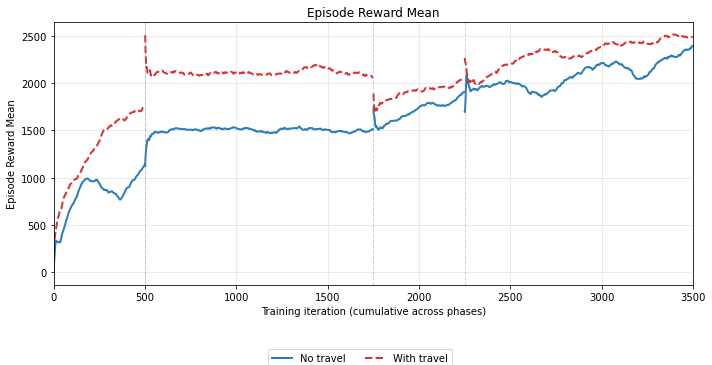

In [ ]:
fig = plotting.compare_training_curves(
    runs,
    metric="episode_reward_mean",
    short_labels=["No travel", "With travel"],
    smooth_window=5,
)

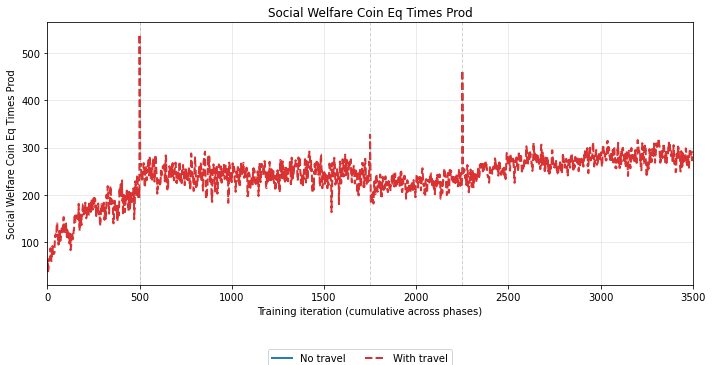

In [ ]:
fig = plotting.compare_training_curves(
    runs,
    metric="social_welfare_coin_eq_times_prod",
    short_labels=["No travel", "With travel"],
    smooth_window=5,
)

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,594.875,167.696632,222.51875,703,283,4759.0,0,6,2,travel-off__regionaltrade-off__layout-stacked_...,500,1250,500,1250
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,743.625,152.040979,265.31625,903,333,5949.0,48,6,2,travel-on__regionaltrade-off__layout-stacked_5...,500,1250,500,1250


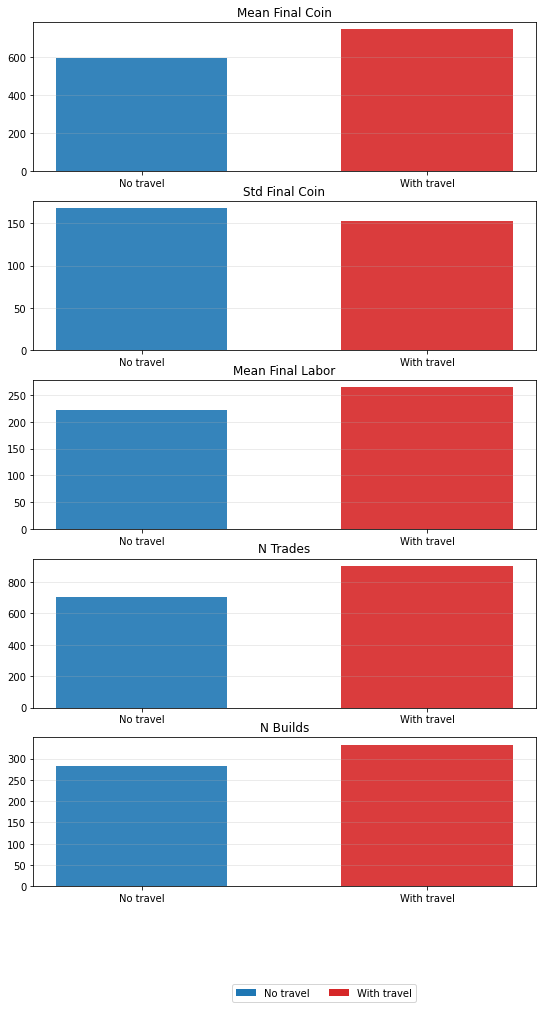

In [ ]:
fig_single, out_single = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar=None,  
)

out_single

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,594.875,167.696632,222.51875,703,283,4759.0,0,6,2,travel-off__regionaltrade-off__layout-stacked_...,500,1250,500,1250
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,743.625,152.040979,265.31625,903,333,5949.0,48,6,2,travel-on__regionaltrade-off__layout-stacked_5...,500,1250,500,1250


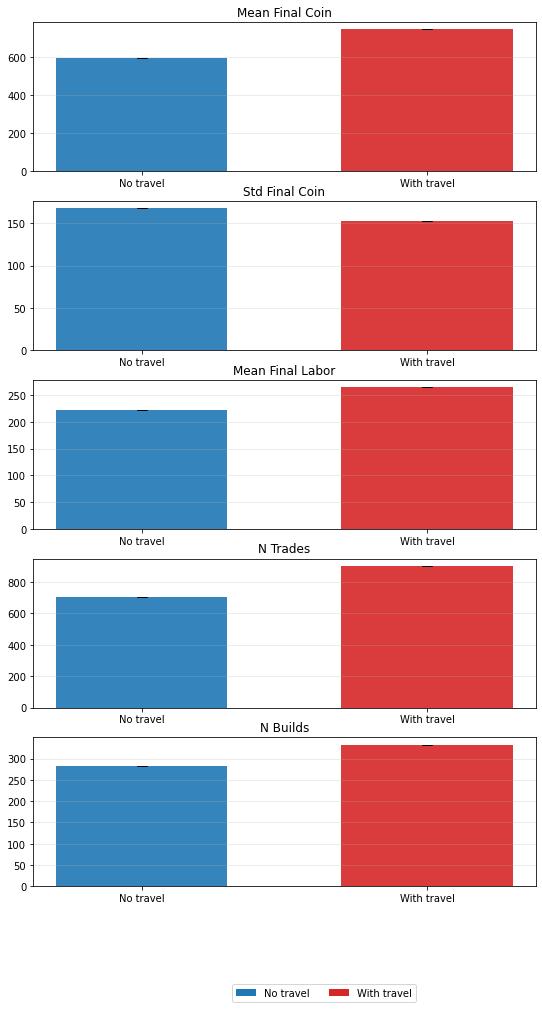

In [ ]:
fig_avg, out_avg = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar="std",  
)

out_avg

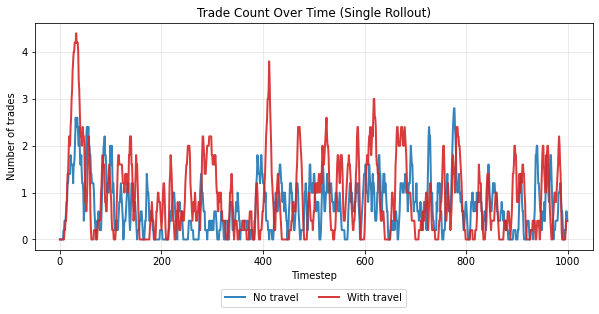

In [ ]:
fig_single = plotting.compare_trade_dynamics(
    runs,
    short_labels=["No travel", "With travel"],
    mode="single",
    smooth_window=5,  
)

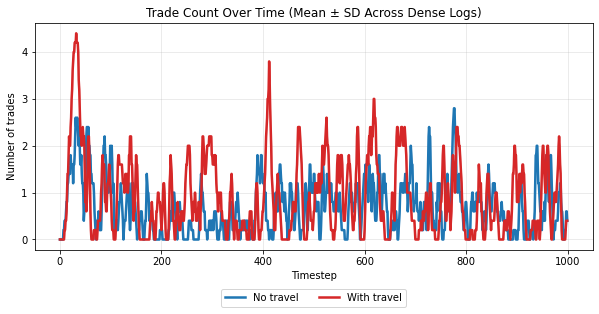

In [ ]:
fig_avg = plotting.compare_trade_dynamics(
    runs,
    short_labels=["No travel", "With travel"],
    mode="average",
    smooth_window=5,
)

,label,gini,error,n_dense_logs
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,0.146544,NaN,1
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,0.102630,NaN,1


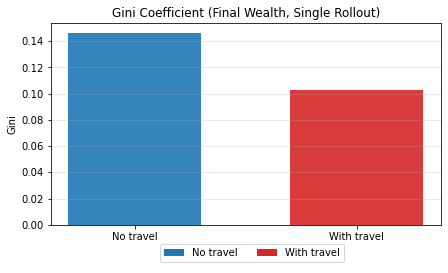

In [ ]:
fig_single, out_single = plotting.compare_gini(
    runs,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    mode="single",
    errorbar=None,
)

out_single

,label,gini,error,n_dense_logs
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,0.146544,0.0,1
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,0.102630,0.0,1


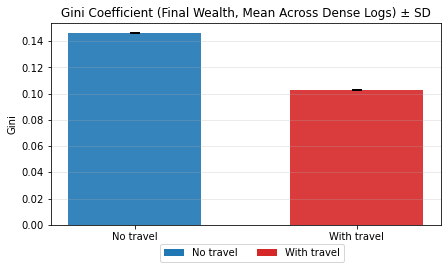

In [ ]:
fig_avg, out_avg = plotting.compare_gini(
    runs,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    mode="average",
    errorbar="std",
)

out_avg

In [ ]:
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

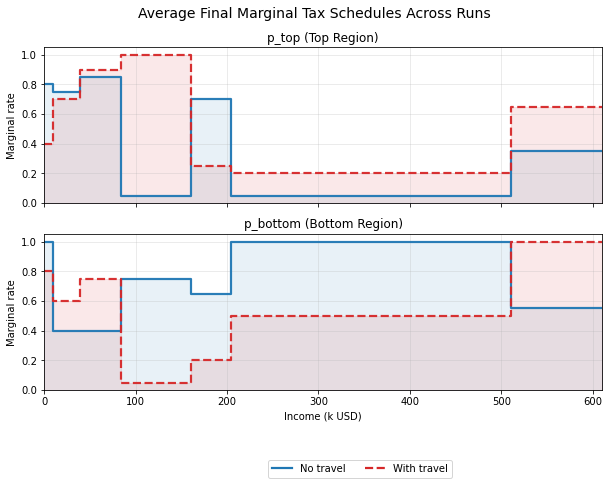

In [ ]:
runs_single = []
for r in runs:
    r_copy = r.copy()
    r_copy["dense_logs"] = {0: r["dense_log"]}  # only one log
    runs_single.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar=None,  
    last_bin_width=100,
)

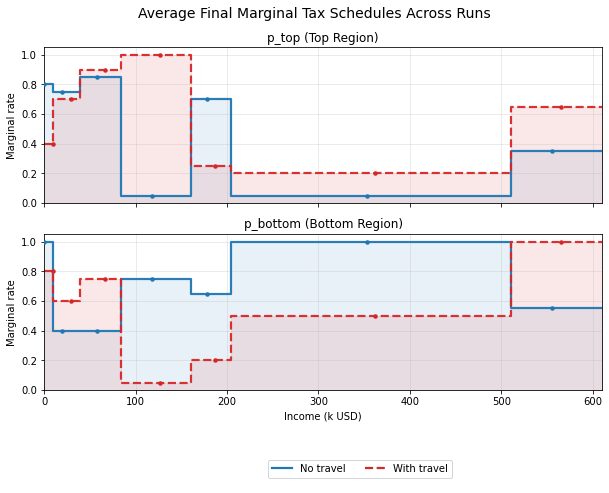

In [ ]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar="std",  
    last_bin_width=100,
)

In [ ]:
from pathlib import Path
import pickle

run_dir = Path(run_dirs[0])   # or your specific results folder

with open(run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

df_income, df_tax_counts = plotting.tax_day_income_report(
    dense_logs[0],
    period=100,
)

df_income.head(20)

,tax_day_number,timestep,agent,region,coin_start,coin_end,income,tax_bracket
0,1,99,0,top,0.00,152.000000,152.000000,"[84.200, 160.725)"
1,1,99,1,top,0.00,140.000000,140.000000,"[84.200, 160.725)"
2,1,99,2,bottom,0.00,139.000000,139.000000,"[84.200, 160.725)"
3,1,99,3,top,0.00,40.000000,40.000000,"[39.475, 84.200)"
4,1,99,4,top,0.00,199.000000,199.000000,"[160.725, 204.100)"
5,1,99,5,bottom,0.00,129.000000,129.000000,"[84.200, 160.725)"
6,1,99,6,top,0.00,170.000000,170.000000,"[160.725, 204.100)"
7,1,99,7,top,0.00,0.000000,0.000000,"[0.000, 9.700)"
8,2,199,0,top,152.00,217.270000,65.270000,"[39.475, 84.200)"
9,2,199,1,top,140.00,142.870000,2.870000,"[0.000, 9.700)"


In [ ]:
df_tax_counts

In [ ]:
all_income = []
all_counts = []

for rollout_id, log in dense_logs.items():
    df_income, df_counts = plotting.tax_day_income_report(log, period=100)

    df_income["rollout_id"] = rollout_id
    df_counts["rollout_id"] = rollout_id

    all_income.append(df_income)
    all_counts.append(df_counts)

df_income_all = pd.concat(all_income, ignore_index=True)
df_tax_counts_all = pd.concat(all_counts, ignore_index=True)

In [ ]:
df_income_all.head(20)
df_tax_counts_all

# Figuring out agent movement

In [ ]:
df_agents, df_summary = plotting.diagnose_agent_activity_df(runs[0]["dense_log"])
df_agents

,agent,movement,coin,wood,stone,labor
0,0,738.0,774.578437,1.0,6.0,225.87
1,1,690.0,636.479687,1.0,7.0,217.51
2,2,494.0,512.367188,3.0,3.0,233.43
3,3,510.0,626.574687,0.0,0.0,199.44
4,4,815.0,797.025000,1.0,5.0,249.07
5,5,149.0,221.192500,28.0,5.0,94.02
6,6,778.0,631.701250,2.0,1.0,321.43
7,7,618.0,559.081250,9.0,2.0,239.38


In [ ]:
all_summaries = []

for run in runs:
    _, df_sum = plotting.diagnose_agent_activity_df(run["dense_log"])
    df_sum["run"] = run["name"]
    all_summaries.append(df_sum)

df_all = pd.concat(all_summaries, ignore_index=True)
df_all

,steps,n_builds,n_trades,n_gathers,avg_movement,total_coin,total_wood,total_stone,run
0,1000,283,703,423,599.00,4759.0,45.0,29.0,travel-off__regionaltrade-off__layout-stacked_...
1,1000,333,903,496,772.75,5949.0,59.0,14.0,travel-on__regionaltrade-off__layout-stacked_5...


In [ ]:
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

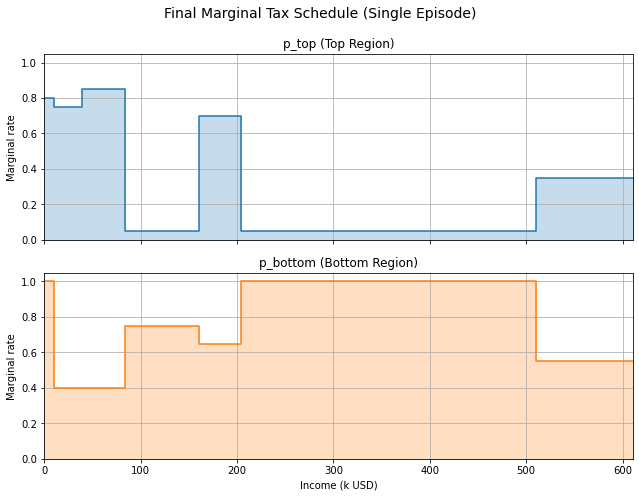

In [ ]:
single_dense_log = {0: dense_logs[0]}  # keep only episode 0

fig_single = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=single_dense_log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final Marginal Tax Schedule (Single Episode)",
    errorbar=None,  
    last_bin_width=100,
)

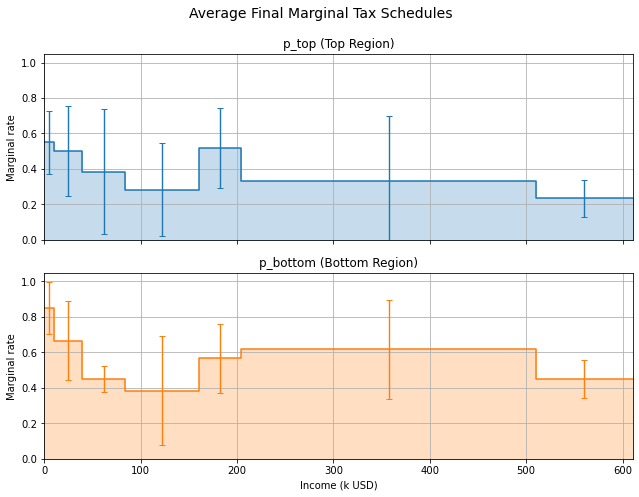

In [ ]:
fig_avg_final = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules",
    errorbar="std",
    last_bin_width=100, 
)

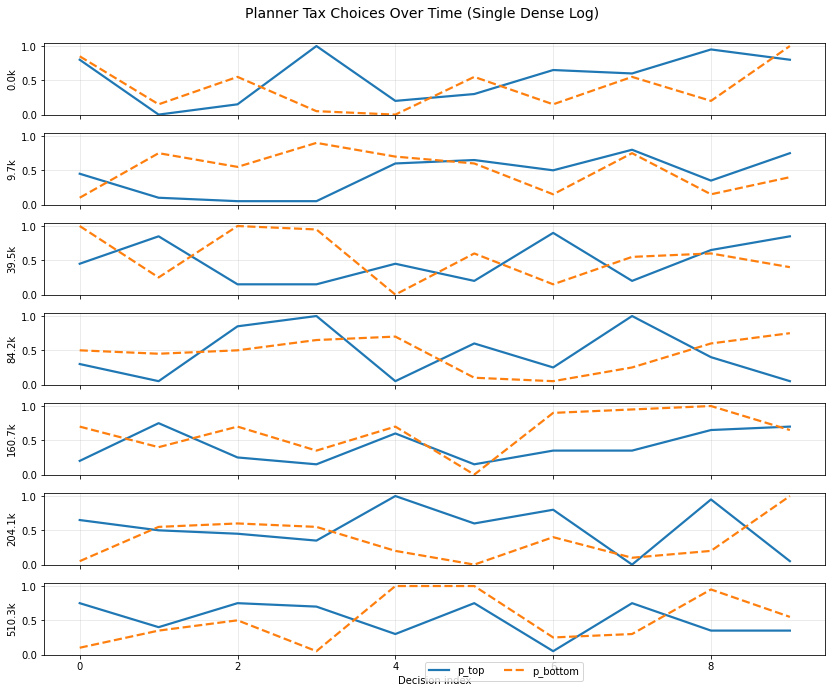

In [ ]:
fig_single = plotting.plot_planner_tax_lines(
    dense_logs={0: dense_logs[0]},
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="single",
    errorbar=None,
    title="Planner Tax Choices Over Time (Single Dense Log)"
)

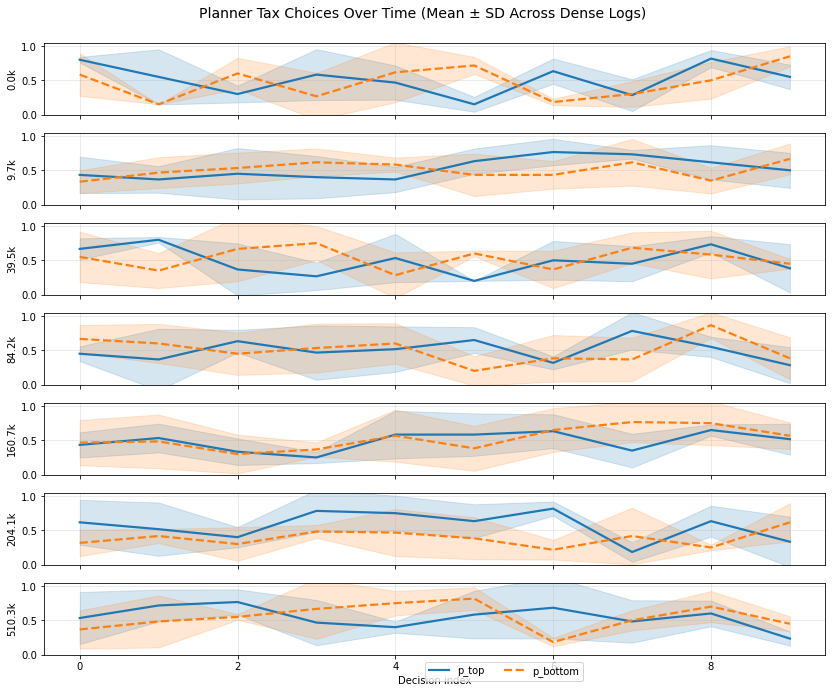

In [ ]:
fig_avg = plotting.plot_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    mode="average",
    errorbar="std",
    title="Planner Tax Choices Over Time (Mean ± SD Across Dense Logs)"
)

In [ ]:
df_regions = plotting.agent_region_time_table(
    runs[0]["dense_log"],
    split_row=25,
    use_region_field=False,
    normalize=True,
)
df_regions

,timesteps_top,timesteps_bottom,total_timesteps,final_region,share_top,share_bottom
agent,,,,,,
0,1001,0,1001,top,1.0,0.0
1,1001,0,1001,top,1.0,0.0
2,1001,0,1001,top,1.0,0.0
3,1001,0,1001,top,1.0,0.0
4,0,1001,1001,bottom,0.0,1.0
5,0,1001,1001,bottom,0.0,1.0
6,0,1001,1001,bottom,0.0,1.0
7,0,1001,1001,bottom,0.0,1.0


In [ ]:
df_spells = plotting.agent_region_spell_table(
    runs[0]["dense_log"],
    split_row=25,
    use_region_field=False,
)
df_spells

,timesteps_top,timesteps_bottom,n_region_switches,n_top_spells,n_bottom_spells,avg_top_spell,avg_bottom_spell,avg_spell_overall,final_region
agent,,,,,,,,,
0,1001,0,0,1,0,1001.0,NaN,1001.0,top
1,1001,0,0,1,0,1001.0,NaN,1001.0,top
2,1001,0,0,1,0,1001.0,NaN,1001.0,top
3,1001,0,0,1,0,1001.0,NaN,1001.0,top
4,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
5,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
6,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
7,0,1001,0,0,1,NaN,1001.0,1001.0,bottom


# single agent single move

In [ ]:
from pathlib import Path

def load_trainer_from_run(run_dir, settings):
    import json

    run_dir = Path(run_dir)  # <-- important fix

    with open(run_dir / "config.json", "r") as f:
        cfg = json.load(f)

    with open(run_dir / "checkpoints.json", "r") as f:
        ckpts = json.load(f)

    env_config = cfg["env_config_dict_phase3b"]

    env_obj = exp.create_env(env_config)

    trainer = exp.create_trainer(
        settings=settings,
        env_config_dict=env_config,
        env_obj=env_obj,
        policies_to_train=["a", "p_top", "p_bottom"],
    )

    trainer.restore(ckpts["phase3b"])

    return trainer, env_obj

In [ ]:
from utils import single

In [ ]:

trainer_phase3b, env_obj_phase3b = load_trainer_from_run(run_dirs[0], settings)

paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

2026-04-24 17:02:57,956	ERROR syncer.py:46 -- Log sync requires rsync to be installed.


In [ ]:
forced_log = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

In [ ]:
df_move_summary = single.forced_move_agent_summary(forced_log, window_before=100, window_after=100)
df_move_summary

,period,agent,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,trade_cashflow
0,before_move,0,100,199,96.000000,10.12,86.350836,0,0.000000,1,12,2,7,96.0
1,after_move,0,201,300,24.633269,22.15,89.388608,1,26.235449,1,0,1,0,-9.0


In [ ]:
df_move_events = single.forced_move_event_table(forced_log, window=80)
df_move_events.head(20)
df_move_events.tail(20)

,t,relative_t,region,coin,wood,stone,labor,utility,built,bought_wood,sold_wood,bought_stone,sold_stone
141,261,61,NaN,302.405924,0.0,0.0,59.19,91.802958,0,0,0,0,0
142,262,62,NaN,302.405924,0.0,0.0,59.40,91.758858,0,0,0,0,0
143,263,63,NaN,302.405924,0.0,0.0,59.61,91.714758,0,0,0,0,0
144,264,64,NaN,302.405924,0.0,0.0,59.82,91.670658,0,0,0,0,0
145,265,65,NaN,302.405924,0.0,0.0,60.03,91.626558,0,0,0,0,0
146,266,66,NaN,302.405924,0.0,0.0,60.24,91.582458,0,0,0,0,0
147,267,67,NaN,302.405924,0.0,0.0,60.45,91.538358,0,0,0,0,0
148,268,68,NaN,302.405924,0.0,0.0,60.66,91.494258,0,0,0,0,0
149,269,69,NaN,302.405924,0.0,0.0,60.87,91.450158,0,0,0,0,0
150,270,70,NaN,302.405924,0.0,0.0,61.08,91.406058,0,0,0,0,0


In [ ]:
forced_log_200 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

forced_log_400 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

forced_log_600 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=600,
    forced_target_region="bottom",
    explore=False,
)

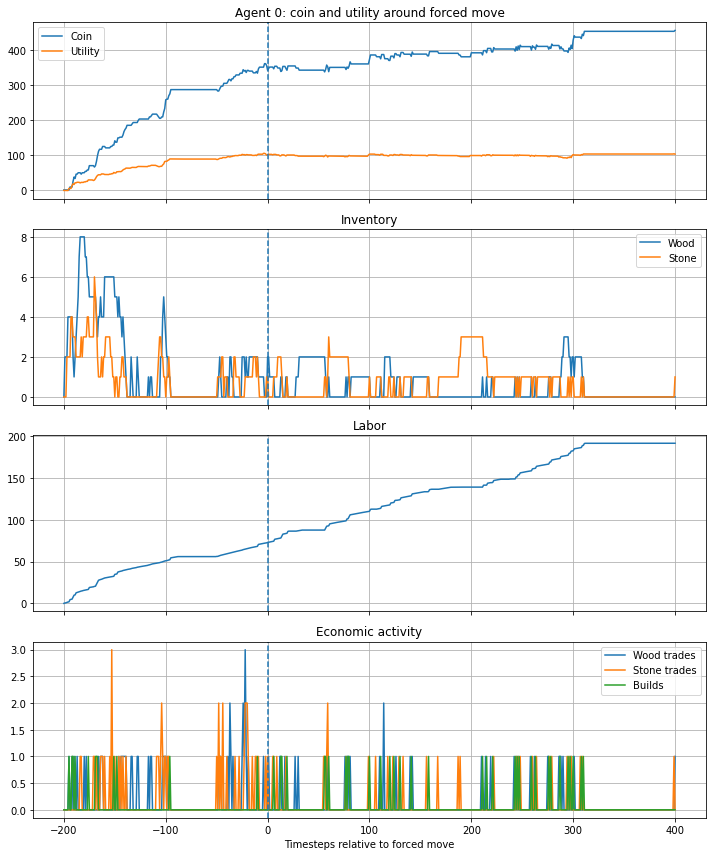

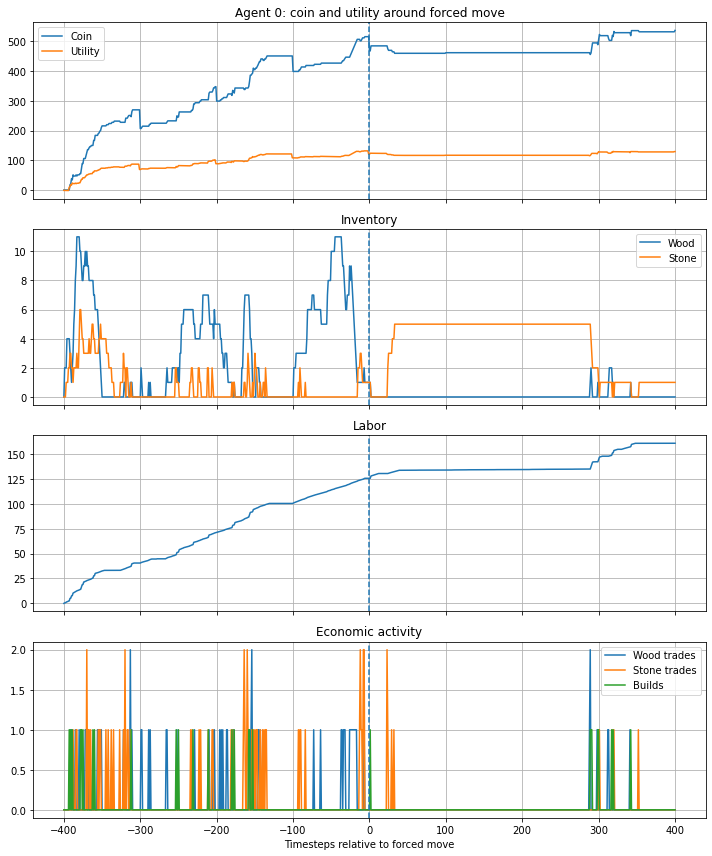

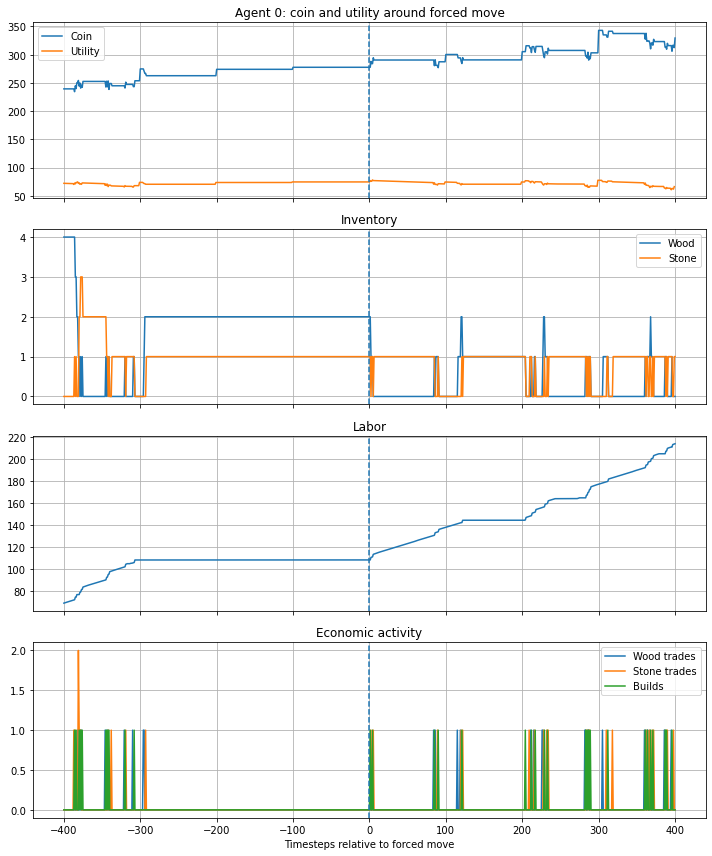

In [ ]:
fig = single.plot_forced_move_timeseries(forced_log_200, window=400)
fig = single.plot_forced_move_timeseries(forced_log_400, window=400)
fig = single.plot_forced_move_timeseries(forced_log_600, window=400)

In [ ]:
df_system = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_system

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1,100,199,96.000000,10.12,86.350836,0,0.000000,22,96.0,1,12,2,7,NaN,NaN
1,moved_agent,after_move,1,201,300,24.633269,22.15,89.388608,1,26.235449,2,-9.0,1,0,1,0,NaN,NaN
2,other_agents,before_move,7,100,199,331.447098,156.26,48.863912,30,427.447098,148,-96.0,45,34,37,32,NaN,NaN
3,other_agents,after_move,7,201,300,184.236258,94.72,57.627584,15,182.634078,52,9.0,10,11,15,16,NaN,NaN


In [ ]:
# use the same moved agent and timestep as in the forced-move run
moved_agent = forced_log["forced_move"]["agent"]
reference_timestep = forced_log["forced_move"]["timestep"]

df_forced = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_baseline = single.baseline_system_summary_table(
    dense_logs,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)

df_baseline

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1.0,100,199,82.000000,21.41,59.429085,0.0,0.0,21.0,82.0,2.0,11.0,0.0,8.0,NaN,NaN
1,moved_agent,after_move,1.0,201,300,56.351562,25.89,63.088270,3.0,33.0,12.0,32.0,1.0,6.0,1.0,4.0,NaN,NaN
2,other_agents,before_move,7.0,100,199,263.000000,150.95,46.880505,21.0,345.0,91.0,-82.0,31.0,22.0,23.0,15.0,NaN,NaN
3,other_agents,after_move,7.0,201,300,267.648438,119.07,54.285228,16.0,307.0,54.0,-32.0,15.0,10.0,16.0,13.0,NaN,NaN
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.319654,31.965417
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.479566,47.956562
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.330092,33.009167
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.334981,33.498125


In [ ]:
df_forced_cmp = df_forced.copy()
df_forced_cmp["run_type"] = "forced_move"

df_baseline_cmp = df_baseline.copy()
df_baseline_cmp["run_type"] = "baseline"

df_compare = pd.concat([df_baseline_cmp, df_forced_cmp], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,100,199,82.000000,21.41,59.429085,0.0,0.000000,21.0,82.0,2.0,11.0,0.0,8.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,201,300,56.351562,25.89,63.088270,3.0,33.000000,12.0,32.0,1.0,6.0,1.0,4.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,100,199,263.000000,150.95,46.880505,21.0,345.000000,91.0,-82.0,31.0,22.0,23.0,15.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,201,300,267.648438,119.07,54.285228,16.0,307.000000,54.0,-32.0,15.0,10.0,16.0,13.0,NaN,NaN,baseline
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.319654,31.965417,baseline
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.479566,47.956562,baseline
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.330092,33.009167,baseline
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.334981,33.498125,baseline
8,moved_agent,before_move,1.0,100,199,96.000000,10.12,86.350836,0.0,0.000000,22.0,96.0,1.0,12.0,2.0,7.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,201,300,24.633269,22.15,89.388608,1.0,26.235449,2.0,-9.0,1.0,0.0,1.0,0.0,NaN,NaN,forced_move


In [ ]:
def forced_move_system_summary_table_no_planner(log, window_before=100, window_after=100):
    """
    Summary table for moved agent, other agents, and both planners
    before vs after a forced move.

    Returns a pandas DataFrame.
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out



    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,

            })


    return pd.DataFrame(rows)

In [ ]:
def baseline_system_summary_table_no_planner(log, moved_agent, reference_timestep, window_before=100, window_after=100, episode_key=0):

    if "states" in log:
        ep_log = log
    elif episode_key in log and isinstance(log[episode_key], dict) and "states" in log[episode_key]:
        ep_log = log[episode_key]
    else:
        ep_log = None
        for v in log.values():
            if isinstance(v, dict) and "states" in v:
                ep_log = v
                break
        if ep_log is None:
            raise ValueError("Could not find a single episode log with key 'states'.")

    t0 = int(reference_timestep)

    states = ep_log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    if moved_agent not in agent_ids:
        raise ValueError(f"moved_agent={moved_agent} not found in baseline log")

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(ep_log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(ep_log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out

    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
            })

    return pd.DataFrame(rows)


In [ ]:
paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

In [ ]:
df_forced = forced_move_system_summary_table_no_planner(
    paired_forced_log,
    window_before=200,
    window_after=200,
)
df_forced["run_type"] = "forced_move"

In [ ]:
moved_agent = paired_forced_log["forced_move"]["agent"]
reference_timestep = paired_forced_log["forced_move"]["timestep"]

df_baseline = baseline_system_summary_table_no_planner(
    paired_baseline_log,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=200,
    window_after=200,
)
df_baseline["run_type"] = "baseline"

In [ ]:
df_compare = pd.concat([df_baseline, df_forced], ignore_index=True)
df_compare

,group,period,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,run_type
0,moved_agent,before_move,0,199,357.206598,78.23,78.246138,14,323.878315,72,140.0,11,28,11,22,baseline
1,moved_agent,after_move,201,400,163.849634,32.36,113.071135,2,46.268331,56,165.0,1,24,15,16,baseline
2,other_agents,before_move,0,199,1056.632325,363.53,33.586212,83,1125.855569,244,-140.0,67,50,69,58,baseline
3,other_agents,after_move,201,400,847.425559,368.90,64.048400,72,965.006862,238,-165.0,67,44,64,63,baseline
4,moved_agent,before_move,0,199,357.206598,78.23,78.246138,14,323.878315,72,140.0,11,28,11,22,forced_move
5,moved_agent,after_move,201,400,137.906042,59.43,112.218121,15,347.012481,27,-174.0,12,0,15,0,forced_move
6,other_agents,before_move,0,199,1056.632325,363.53,33.586212,83,1125.855569,244,-140.0,67,50,69,58,forced_move
7,other_agents,after_move,201,400,548.516345,204.94,62.321402,25,339.409907,133,174.0,20,32,33,48,forced_move


,t,relative_t,moved_agent_utility,other_agents_avg_utility,p_top_reward,p_bottom_reward
0,100,-100,73.197817,43.067121,NaN,NaN
1,101,-99,78.261592,42.627200,NaN,NaN
2,102,-98,78.765536,43.080655,NaN,NaN
3,103,-97,81.485249,43.141017,NaN,NaN
4,104,-96,83.104838,42.694441,NaN,NaN


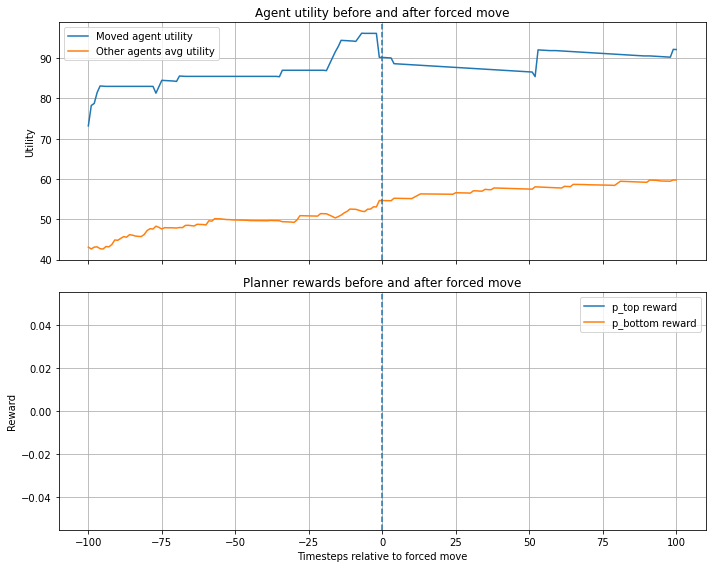

In [ ]:
fig, df_util = single.plot_forced_move_utilities_system(forced_log, window=100)
df_util.head()

In [ ]:
df_delta = single.forced_move_delta_table(forced_log, window_before=100, window_after=100)
df_delta

,group,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,0,101,101,-71.366731,12.03,3.037772,1,26.235449,-20,-105.0,0,-12,-1,-7,NaN,NaN
1,other_agents,0,101,101,-147.210840,-61.54,8.763672,-15,-244.813020,-96,105.0,-35,-23,-22,-16,NaN,NaN
